In [1]:
# For downloading as PDF
# !jupyter nbconvert --to html HaroonParvezFinalProject.ipynb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear

In [3]:
# Loading each Raman spectrum from its sheet
log_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name='ec_log_mean raman')
sta_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name='ec_sta_mean raman')
ref_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name="tbl_15components")

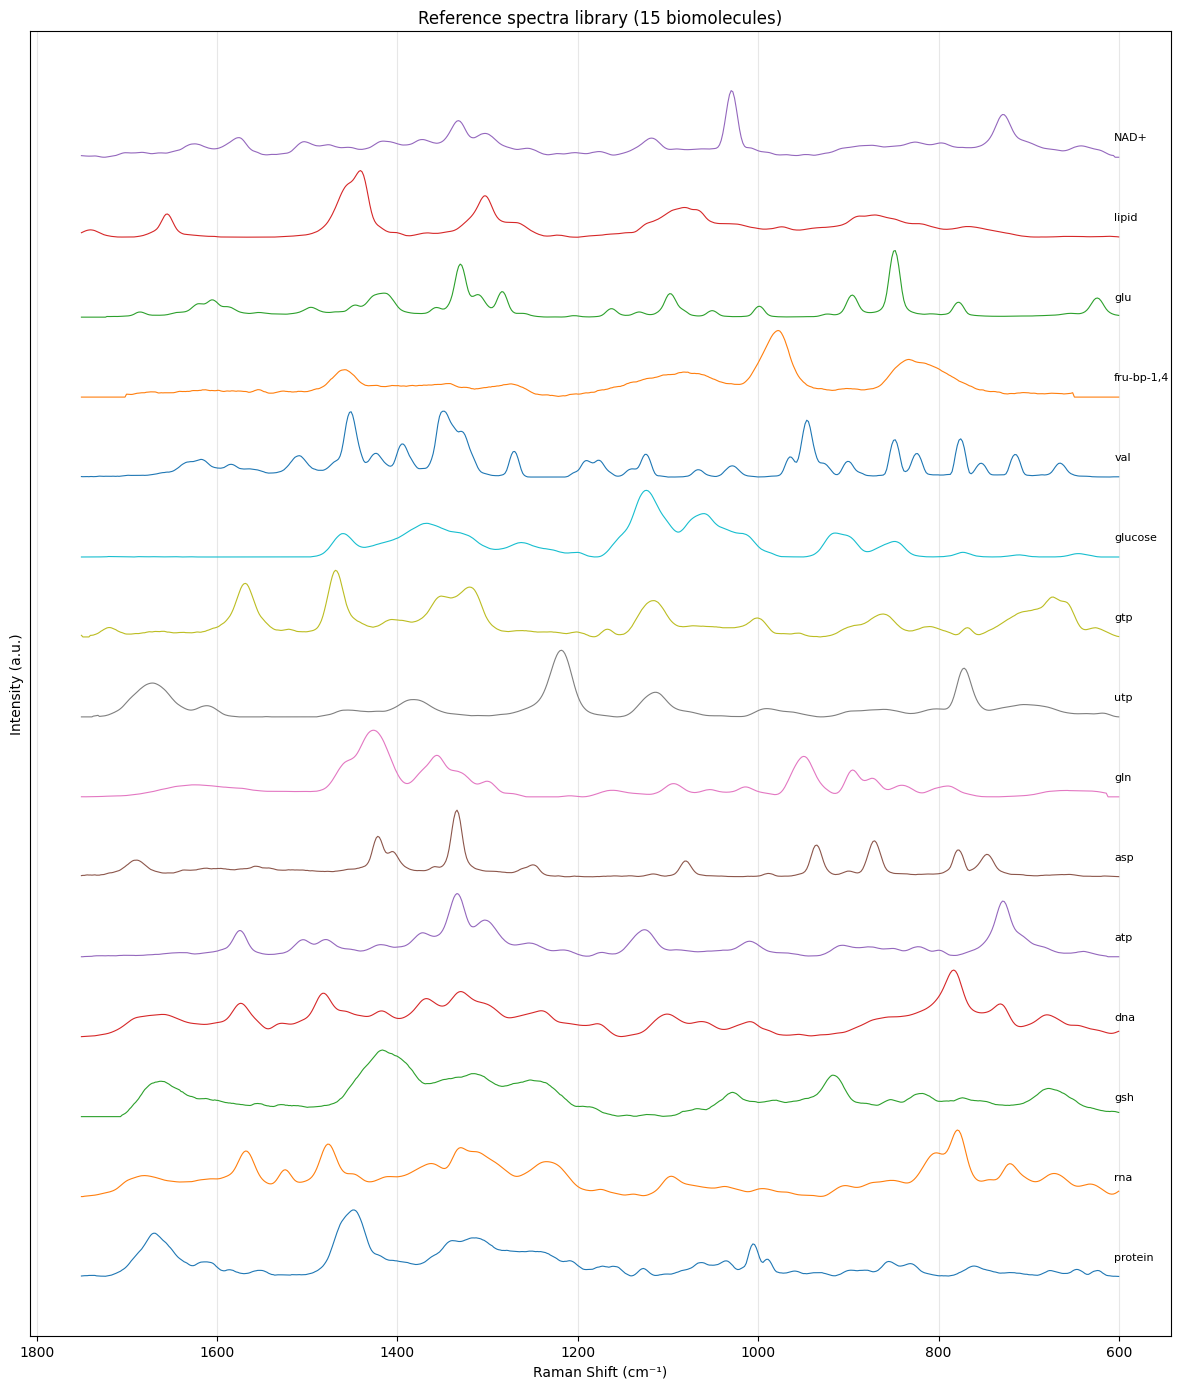

In [4]:
# Extracting wavenumber axis and biomolecule names from reference spectra (tbl_15components)
wn = ref_df["wavenumber"].values
ref_names = [name for name in ref_df.columns if name != "wavenumber"]

# Waterfall plot: each reference spectrum offset vertically for clarity
offset = 1.2  # vertical spacing between spectra

plt.figure(figsize=(12, 14))
for number, name in enumerate(ref_names):
    plt.plot(wn, ref_df[name] + number * offset, linewidth=0.8, label=name)
    plt.text(wn[-1] + 5, number * offset + 0.3, name, fontsize=8, va='center')

plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("Reference spectra library (15 biomolecules)")
plt.yticks([])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

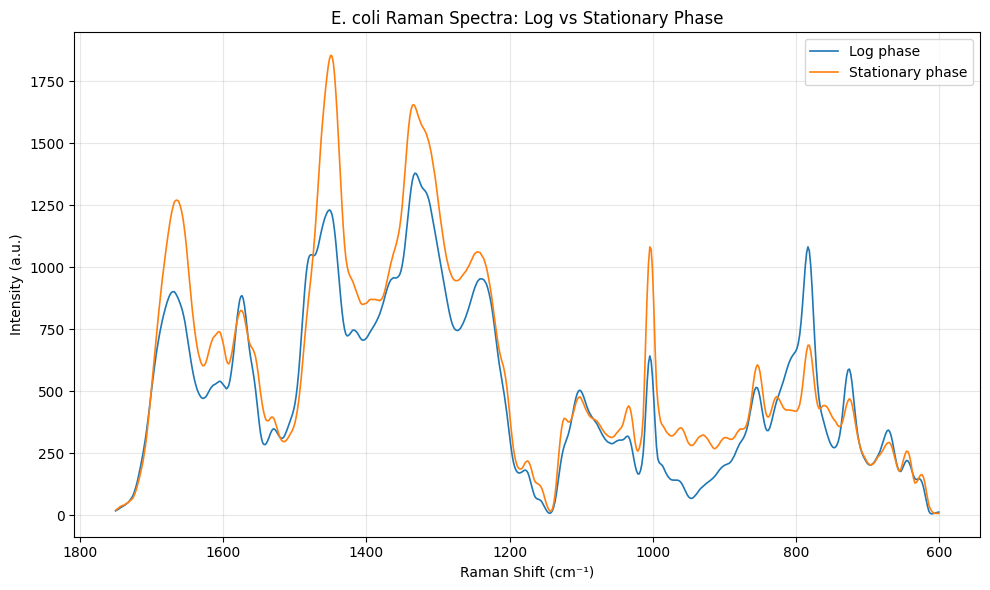

In [5]:
# Column names
log_df.columns = ["wavenumber", "intensity"]
sta_df.columns = ["wavenumber", "intensity"]

# Sort by ascending wavenumber
log_df = log_df.sort_values("wavenumber").reset_index(drop=True)
sta_df = sta_df.sort_values("wavenumber").reset_index(drop=True)

# Ensure reference spectra match ascending wavenumber order
ref_df = ref_df.sort_values("wavenumber").reset_index(drop=True)

# Reference spectra matrix (637 data points x 15 biomolecules)
R = ref_df[ref_names].values

# Plot raw spectra
plt.figure(figsize=(10, 6))
plt.plot(log_df["wavenumber"], log_df["intensity"], label="Log phase", linewidth=1.2)
plt.plot(sta_df["wavenumber"], sta_df["intensity"], label="Stationary phase", linewidth=1.2)
plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("E. coli Raman Spectra: Log vs Stationary Phase")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

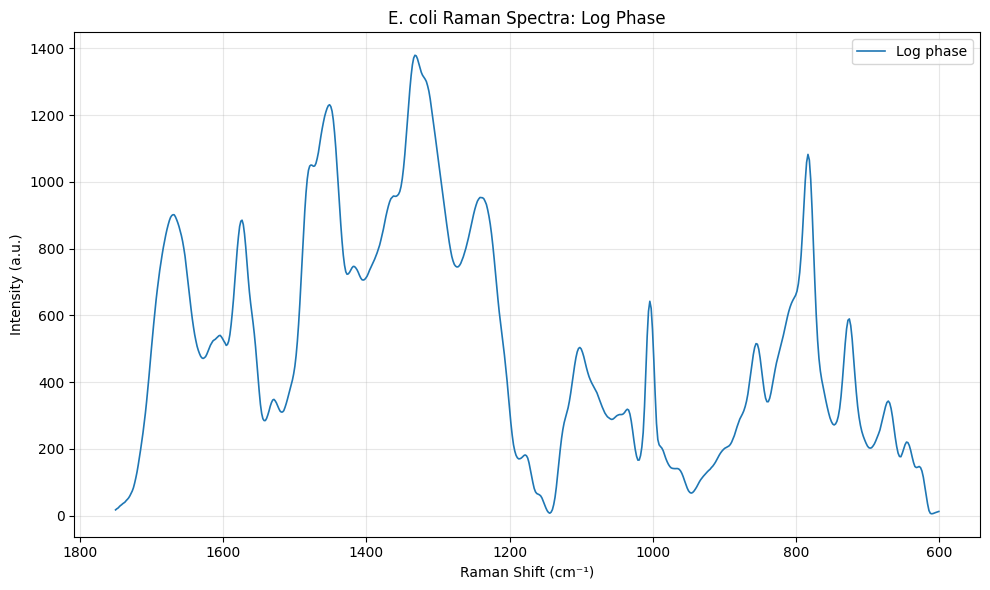

In [25]:
# Plot raw spectra
plt.figure(figsize=(10, 6))
plt.plot(log_df["wavenumber"], log_df["intensity"], label="Log phase", linewidth=1.2)
plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("E. coli Raman Spectra: Log Phase")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Nyquist criterion for Raman
# dnu = np.mean(np.diff(x))  # wavenumber spacing
# Delta_nu = x.max() - x.min()  # total wavenumber range

# Fourier conjugate spacing
# Delta_t = 1.0 / dnu  # range in Fourier space (from sampling theorem)

# N_ind = (2.0 / np.pi) * Delta_nu * Delta_t

# print(f"Wavenumber spacing dν = {dnu:.4f} cm⁻¹")
# print(f"Wavenumber range Δν = {Delta_nu:.2f} cm⁻¹")
#print(f"Fourier range Δt = 1/dν = {Delta_t:.4f} cm")
#print(f"N_ind = (2/π) × Δν × Δt = {N_ind:.1f}")
#print(f"N_data = {len(x)}")

## Normalisation

In [7]:
# Normalise intensities so max = 1, matching reference spectra which has been normalised already
log_df["intensity_norm"] = log_df["intensity"] / log_df["intensity"].max()
sta_df["intensity_norm"] = sta_df["intensity"] / sta_df["intensity"].max()

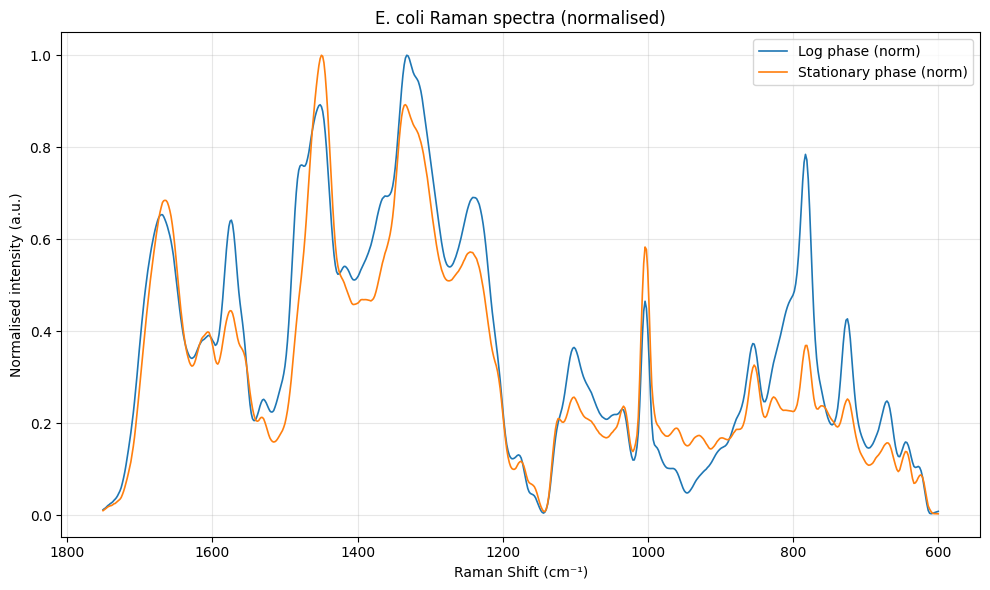

In [8]:
# Plotting with normalised data

plt.figure(figsize=(10, 6))
plt.plot(log_df["wavenumber"], log_df["intensity_norm"], label="Log phase (norm)", linewidth=1.2)
plt.plot(sta_df["wavenumber"], sta_df["intensity_norm"], label="Stationary phase (norm)", linewidth=1.2)

plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Normalised intensity (a.u.)")
plt.title("E. coli Raman spectra (normalised)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Fitting and BFI

## Log Spectra Fitting

LOG PHASE: BFI forward selection
Data points: 637, Baseline degree: 2
Priors: baseline Δb = 1.0, biomolecule ΔA = 1.0

step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI
------------------------------------------------------------------------------------------
   0      (baseline)   3     3   3.76e+00   3.070e+01  4.842e-02     52.2913         -
   1             dna   4     4   6.52e+00   7.866e+00  1.243e-02    481.1738   428.8825
   2         protein   5     5   7.85e+00   2.502e+00  3.958e-03    840.4828   359.3090
   3             rna   6     6   1.95e+01   1.567e+00  2.484e-03    985.3981   144.9153
   4             gsh   7     7   2.02e+01   1.344e+00  2.133e-03   1030.3691    44.9710
   5             atp   8     8   2.04e+01   1.205e+00  1.915e-03   1061.2575    30.8884
   6             utp   9     9   2.06e+01   1.153e+00  1.836e-03   1071.4983    10.2409
   7             gtp  10    10   2.15e+01   1.112e+00  1.774e-03   1079.1895     7.6912

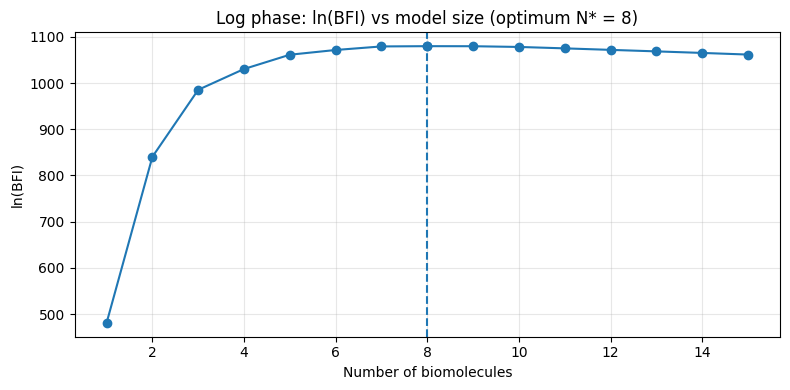

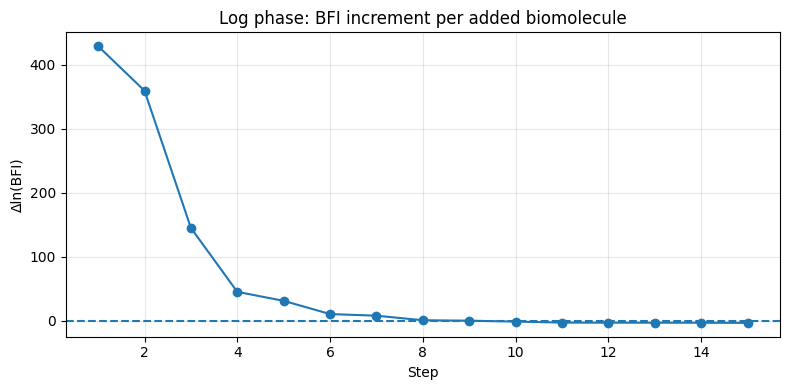

In [9]:
# ===========================
# SETTINGS
# ===========================
x            = log_df["wavenumber"].values
y            = log_df["intensity_norm"].values
bmax         = 0.5              # baseline coefficients range: -bmax to +bmax
Amax         = 1.0              # biomolecule coefficients range: 0 to Amax
baseline_deg = 2                # degree-2 polynomial baseline (constant + linear + quadratic)
n_base = baseline_deg + 1       # 3 baseline parameters (b₀, b₁, b₂)

n      = len(x)                 # number of data points (637)

# ===========================
# FUNCTIONS
# ===========================

def scale_wn(x):
    """Scale wavenumbers (x-axis) to [-1, 1] for numerical stability of polynomial baseline."""
    return 2*(x-x.min())/(x.max()-x.min())-1.0

def build_design_matrix(x, ref_matrix, selected_columns, deg):
    """
    Build standard design matrix: [baseline columns | selected reference spectra].
    Baseline is a quadratic polynomial in scaled wavenumber from above function.
    Each selected reference spectrum becomes one column.
    """
    xs = scale_wn(x)
    baseline = np.vstack([xs**i for i in range(deg + 1)]).T
    if len(selected_columns) > 0:
        spectra = ref_matrix[:, selected_columns]
    else:
        spectra = np.zeros((len(x), 0))
    return np.hstack([baseline, spectra])

def fit_model(X, y, n_base):
    """
    Non-negative bounded least squares.
    Baseline coefficients are unconstrained; biomolecule coefficients >= 0
    (negative concentrations are unphysical).
    Returns fitted parameters, predictions, residual statistics, and covariance matrix.
    """
    k = X.shape[1]
    lower_bounds = np.full(k, -np.inf)
    upper_bounds = np.full(k,  np.inf)
    lower_bounds[n_base:] = 0.0  # enforce non-negativity on biomolecule coefficients

    result = lsq_linear(X, y, bounds=(lower_bounds, upper_bounds), lsmr_tol='auto', verbose=0)
    beta = result.x
    yhat = X @ beta
    RSS  = float(np.sum((y - yhat)**2))       # residual sum of squares
    dof  = max(n - k, 1)                       # degrees of freedom
    s2   = RSS / dof                           # noise variance estimate (plug-in for σ²)

    # Parameter covariance matrix: Cov = s² × (XᵀX)⁻¹
    XtX = X.T @ X
    try:
        XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        XtX_inv = np.linalg.pinv(XtX)

    covariance = s2 * XtX_inv
    condition  = float(np.linalg.cond(X))      # condition number (check for ill-conditioning)
    rank       = np.linalg.matrix_rank(X)
    return beta, yhat, RSS, s2, covariance, rank, condition

def ln_bfi(s2, covariance, prior_widths, n, k):
    """
    Log Bayes Factor Integral (Mayerl, Sapelkin et al. 2024, Eq. 6):
        ln(BFI) = ln(L_max) + (k/2)ln(2π) + (1/2)ln(det(Cov)) - Σln(Δpᵢ)

    Noise variance σ² is unknown, so we use the plug-in estimator s² = RSS/(n-k).
    The Occam factor naturally penalises models with too many or correlated parameters.
    """
    dof = n - k
    if dof <= 0 or s2 <= 0 or not np.isfinite(s2):
        return np.nan

    sign, logdet = np.linalg.slogdet(covariance)
    if sign != 1 or not np.isfinite(logdet):
        return np.nan

    # Term 1: Log-likelihood at best fit (with σ² replaced by s² in BFI formula)
    ln_likelihood = -0.5 * n * np.log(2*np.pi) - 0.5 * n * np.log(s2) - 0.5 * dof

    # Term 2: Occam factor - rewards tight parameter constraints, penalises correlations
    ln_occam = 0.5 * k * np.log(2*np.pi) + 0.5 * logdet

    # Term 3: Prior normalisation - wider priors penalise the model more
    ln_prior = -np.sum(np.log(prior_widths))

    return float(ln_likelihood + ln_occam + ln_prior)

# ===========================
# FORWARD SELECTION METHOD: Start with baseline only, add one biomolecule per step,
# (whichever maximises ln(BFI)), stop when no addition improves the score.
# ===========================

# Start with baseline-only model (no biomolecules)
selected = []
history  = []

X0 = build_design_matrix(x, R, [], baseline_deg)
beta0, yhat0, RSS0, s20, covariance0, rank0, condition0 = fit_model(X0, y, n_base)
prior0     = np.array([2*bmax] * n_base)       # baseline prior widths
lnBFI_0    = ln_bfi(s20, covariance0, prior0, n=n, k=X0.shape[1])
prev_lnBFI = lnBFI_0

print("LOG PHASE: BFI forward selection")
print(f"Data points: {n}, Baseline degree: {baseline_deg}")
print(f"Priors: baseline Δb = {2*bmax}, biomolecule ΔA = {Amax}")
print()
print("step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI")
print("-" * 90)
print(f"   0  {'(baseline)':>14s}  {X0.shape[1]:>2d}  {rank0:>4d}  {condition0:>9.2e}  {RSS0:>10.3e}  {s20:>9.3e}  {lnBFI_0:>10.4f}         -")

# At each step, try every remaining biomolecule
# and add whichever gives the largest increase in ln(BFI)
for step in range(1, R.shape[1] + 1):
    best = None

    for column in range(R.shape[1]):
        if column in selected:
            continue

        # Trial model: current selection + this candidate
        trial = selected + [column]
        X = build_design_matrix(x, R, trial, baseline_deg)
        beta, yhat, RSS, s2, covariance, rank, condition = fit_model(X, y, n_base)

        # Prior widths: baseline gets Δb = 2×bmax, each biomolecule gets ΔA = Amax
        prior = np.array([2*bmax]*n_base + [Amax]*len(trial))
        lnBFI = ln_bfi(s2, covariance, prior, n=n, k=X.shape[1])

        if not np.isfinite(lnBFI):
            continue

        # Keep track of the best candidate this step
        delta = lnBFI - prev_lnBFI
        if best is None or delta > best[0]:
            best = (delta, lnBFI, column, X.shape[1], rank, condition, RSS, s2, yhat, beta)

    if best is None:
        break

    # Lock in the best candidate and record results
    delta, lnBFI, column, k, rank, condition, RSS, s2, yhat, beta = best
    selected.append(column)
    history.append((step, column, ref_names[column], lnBFI, delta, k, rank, condition, RSS, s2, yhat, beta))
    print(f"{step:>4d}  {ref_names[column]:>14s}  {k:>2d}  {rank:>4d}  {condition:>9.2e}  {RSS:>10.3e}  {s2:>9.3e}  {lnBFI:>10.4f}  {delta:>9.4f}")
    prev_lnBFI = lnBFI

# ===========================
# FIND OPTIMUM MODEL + SELECTED BIOMOLECULES
# ===========================
# N* = number of biomolecules at maximum ln(BFI)
steps_arr = np.array([h[0] for h in history])
lnBFI_arr = np.array([h[3] for h in history])
delta_arr = np.array([h[4] for h in history])

best_step = int(np.nanargmax(lnBFI_arr))
N_star     = int(steps_arr[best_step])
ln_star    = float(lnBFI_arr[best_step])

selected_names = [history[i][2] for i in range(N_star)]
print(f"\nOptimal model: N* = {N_star} biomolecules, lnBFI = {ln_star:.4f}")
print("Selected:", selected_names)

# ===========================
# PLOTS
# ===========================

# ln(BFI) vs model size - peak indicates optimal complexity
plt.figure(figsize=(8, 4))
plt.plot(steps_arr, lnBFI_arr, marker="o")
plt.axvline(N_star, linestyle="--")
plt.scatter([N_star], [ln_star], zorder=5)
plt.xlabel("Number of biomolecules")
plt.ylabel("ln(BFI)")
plt.title(f"Log phase: ln(BFI) vs model size (optimum N* = {N_star})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Incremental gain - shows diminishing returns and where BFI starts declining
plt.figure(figsize=(8, 4))
plt.plot(steps_arr, delta_arr, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Δln(BFI)")
plt.title("Log phase: BFI increment per added biomolecule")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

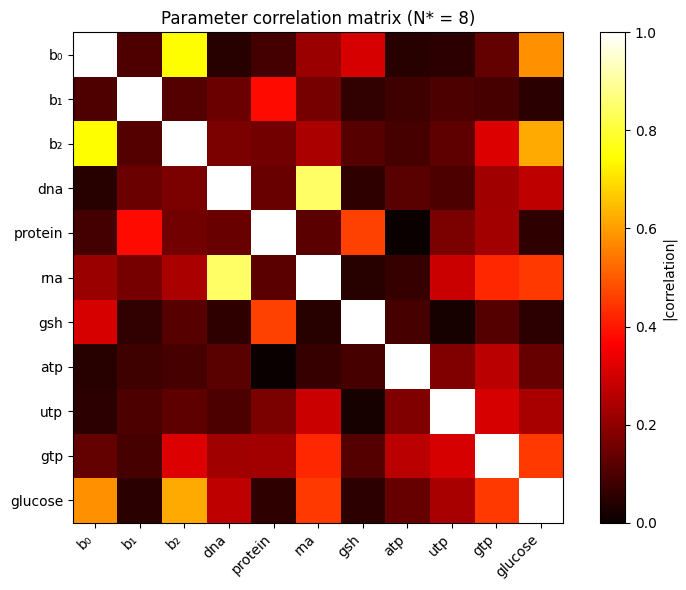

In [10]:
# Correlation matrix at optimal model N*
# Shows how strongly each parameter's estimate depends on others

X_star = build_design_matrix(x, R, selected[:N_star], baseline_deg)
_, _, _, s2_star, covariance_star, _, _ = fit_model(X_star, y, n_base)

# Convert covariance to correlation (normalise to [-1, 1])
diag = np.sqrt(np.diag(covariance_star))
corr_matrix = covariance_star / np.outer(diag, diag)

# Parameter labels for axes
param_labels = ["b₀", "b₁", "b₂"] + selected_names

plt.figure(figsize=(8, 6))
plt.imshow(np.abs(corr_matrix), cmap='hot', vmin=0, vmax=1)
plt.colorbar(label="|correlation|")
plt.xticks(range(len(param_labels)), param_labels, rotation=45, ha='right')
plt.yticks(range(len(param_labels)), param_labels)
plt.title(f"Parameter correlation matrix (N* = {N_star})")
plt.tight_layout()
plt.show()

In [11]:
# ===========================
# LOG PHASE: RESULTS SUMMARY
# ===========================
best_entry = history[best_step]
k_best   = best_entry[5]
RSS_best = best_entry[8]
s2_best  = best_entry[9]

print("=" * 70)
print("LOG PHASE RESULTS SUMMARY")
print("=" * 70)
print(f"Optimal number of biomolecules: N* = {N_star}")
print(f"Maximum ln(BFI): {ln_star:.2f}")
print(f"Data points: n = {n}")
print(f"Total parameters: k = {k_best} (3 baseline + {N_star} biomolecules)")
print(f"RSS: {RSS_best:.4f}")
print(f"Noise estimate: s² = {s2_best:.6f}")

print(f"\nSelected biomolecules (in order of selection):")
for i in range(N_star):
    print(f"  {i+1}. {history[i][2]}")

LOG PHASE RESULTS SUMMARY
Optimal number of biomolecules: N* = 8
Maximum ln(BFI): 1079.77
Data points: n = 637
Total parameters: k = 11 (3 baseline + 8 biomolecules)
RSS: 1.0979
Noise estimate: s² = 0.001754

Selected biomolecules (in order of selection):
  1. dna
  2. protein
  3. rna
  4. gsh
  5. atp
  6. utp
  7. gtp
  8. glucose


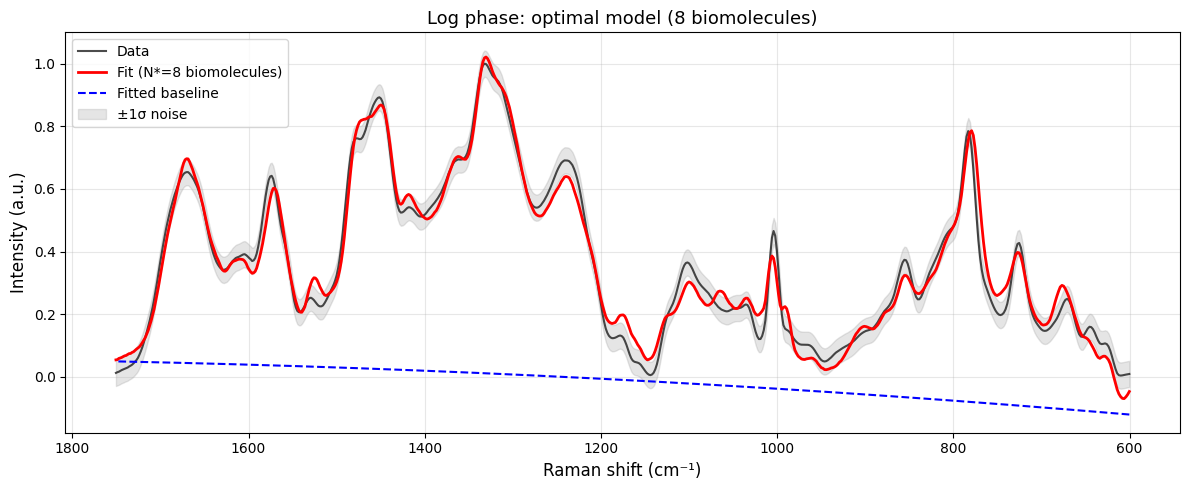

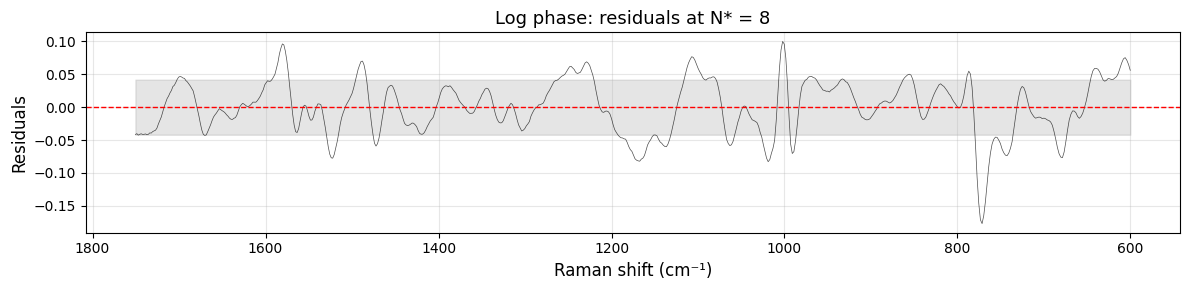

In [12]:
# Fit and residual plots for log phase at optimal model
yhat_best = history[best_step][10]
beta_best = history[best_step][11]
residuals = y - yhat_best

# Extract fitted baseline: b₀ + b₁x̃ + b₂x̃²
xs = scale_wn(x)
baseline_fit = beta_best[0] + beta_best[1]*xs + beta_best[2]*xs**2

# Top: data vs fitted spectrum with baseline
plt.figure(figsize=(12, 5))
plt.plot(x, y, 'k-', linewidth=1.5, label='Data', alpha=0.7)
plt.plot(x, yhat_best, 'r-', linewidth=2, label=f'Fit (N*={N_star} biomolecules)')
plt.plot(x, baseline_fit, 'b--', linewidth=1.5, label='Fitted baseline')
plt.fill_between(x, y - np.sqrt(s2_best), y + np.sqrt(s2_best),
                 alpha=0.2, color='gray', label=r'±1σ noise')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.title(f'Log phase: optimal model ({N_star} biomolecules)', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bottom: residuals — should be random and mostly within ±1σ band
plt.figure(figsize=(12, 3))
plt.plot(x, residuals, 'k-', linewidth=0.5, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.fill_between(x, -np.sqrt(s2_best), +np.sqrt(s2_best),
                 alpha=0.2, color='gray')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title(f'Log phase: residuals at N* = {N_star}', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Log Phase: Coefficient Analysis
## How much does each biomolecule contribute?

LOG PHASE: COEFFICIENTS AT N* = 8

Baseline coefficients:
  b0 = -0.0099
  b1 = 0.0849
  b2 = -0.0258

Biomolecule coefficients:
  Biomolecule     Coefficient % of total
----------------------------------------
  dna                  0.3955      24.4%
  protein              0.4751      29.3%
  rna                  0.4092      25.2%
  gsh                  0.1148       7.1%
  atp                  0.0949       5.8%
  utp                  0.0621       3.8%
  gtp                  0.0370       2.3%
  glucose              0.0354       2.2%

  Total: 1.6240


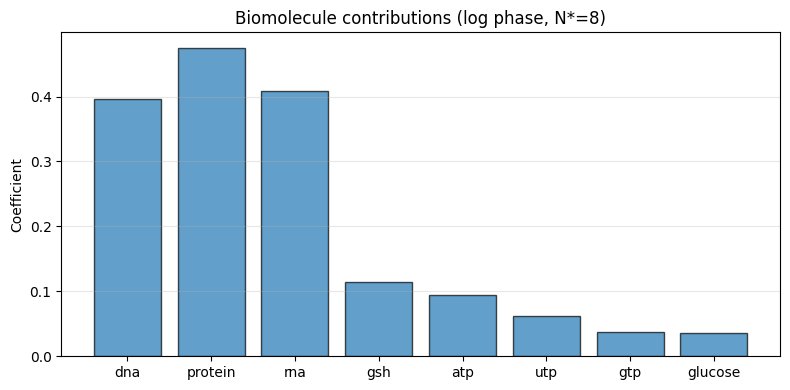

In [13]:
# Extract fitted coefficients at optimal model
beta_best = history[best_step][11]
baseline_coeffs = beta_best[:n_base]
coeffs_best = beta_best[n_base:]

print("=" * 60)
print(f"LOG PHASE: COEFFICIENTS AT N* = {N_star}")
print("=" * 60)

print(f"\nBaseline coefficients:")
for i, b in enumerate(baseline_coeffs):
    print(f"  b{i} = {b:.4f}")

print(f"\nBiomolecule coefficients:")
print(f"  {'Biomolecule':<14s} {'Coefficient':>12s} {'% of total':>10s}")
print("-" * 40)
total = coeffs_best.sum()
for name, c in zip(selected_names, coeffs_best):
    print(f"  {name:<14s} {c:>12.4f} {c/total*100:>9.1f}%")

print(f"\n  Total: {total:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(selected_names, coeffs_best, edgecolor='black', alpha=0.7)
plt.ylabel('Coefficient')
plt.title(f'Biomolecule contributions (log phase, N*={N_star})')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Stationary Data Fitting

STATIONARY PHASE: BFI forward selection
Data points: 637
Priors: baseline Δb = 1.0, biomolecule ΔA = 1.0

step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI
------------------------------------------------------------------------------------------
   0      (baseline)   3     3   3.76e+00   2.312e+01  3.647e-02    142.1774         -
   1         protein   4     4   6.54e+00   5.418e+00  8.560e-03    599.1420   456.9645
   2             rna   5     5   7.40e+00   2.093e+00  3.311e-03    896.7482   297.6062
   3             gsh   6     6   8.91e+00   1.561e+00  2.474e-03    985.7933    89.0451
   4             atp   7     7   9.29e+00   1.311e+00  2.080e-03   1037.5669    51.7736
   5             dna   8     8   2.04e+01   1.242e+00  1.974e-03   1051.7700    14.2031
   6             gtp   9     9   2.12e+01   1.186e+00  1.889e-03   1062.5853    10.8153
   7      fru-bp-1,4  10    10   2.18e+01   1.146e+00  1.828e-03   1069.8729     7.2876
   8        

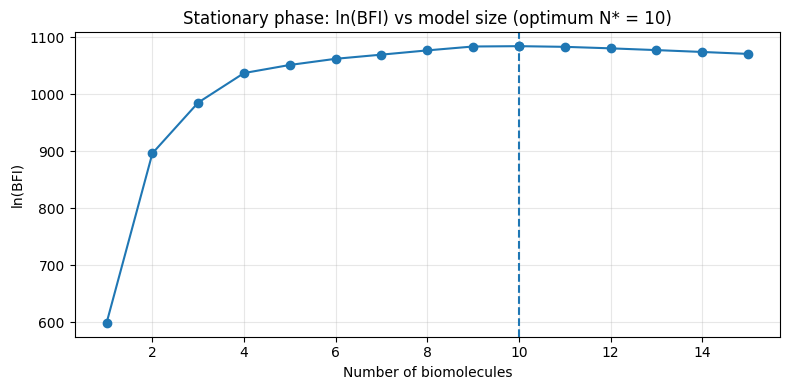

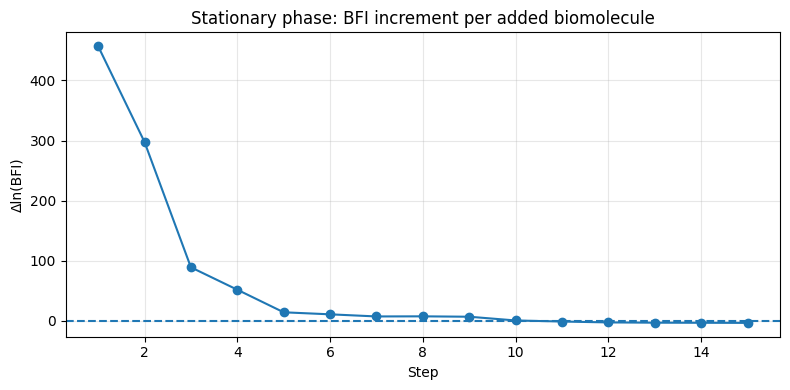

In [14]:
# ===========================
# STATIONARY PHASE: Same procedure as log phase
# ===========================
y_sta = sta_df["intensity_norm"].values

selected_sta = []
history_sta  = []

# Step 0: baseline-only model
X0 = build_design_matrix(x, R, [], baseline_deg)
beta0, yhat0, RSS0, s20, covariance0, rank0, condition0 = fit_model(X0, y_sta, n_base)
prior0         = np.array([2*bmax] * n_base)
lnBFI_0        = ln_bfi(s20, covariance0, prior0, n=n, k=X0.shape[1])
prev_lnBFI_sta = lnBFI_0

print("STATIONARY PHASE: BFI forward selection")
print(f"Data points: {n}")
print(f"Priors: baseline Δb = {2*bmax}, biomolecule ΔA = {Amax}")
print()
print("step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI")
print("-" * 90)
print(f"   0  {'(baseline)':>14s}  {X0.shape[1]:>2d}  {rank0:>4d}  {condition0:>9.2e}  {RSS0:>10.3e}  {s20:>9.3e}  {lnBFI_0:>10.4f}         -")

for step in range(1, R.shape[1] + 1):
    best = None

    for column in range(R.shape[1]):
        if column in selected_sta:
            continue

        trial = selected_sta + [column]
        X = build_design_matrix(x, R, trial, baseline_deg)
        beta, yhat, RSS, s2, covariance, rank, condition = fit_model(X, y_sta, n_base)

        prior = np.array([2*bmax]*n_base + [Amax]*len(trial))
        lnBFI = ln_bfi(s2, covariance, prior, n=n, k=X.shape[1])

        if not np.isfinite(lnBFI):
            continue

        delta = lnBFI - prev_lnBFI_sta
        if best is None or delta > best[0]:
            best = (delta, lnBFI, column, X.shape[1], rank, condition, RSS, s2, yhat, beta)

    if best is None:
        break

    delta, lnBFI, column, k, rank, condition, RSS, s2, yhat, beta = best
    selected_sta.append(column)
    history_sta.append((step, column, ref_names[column], lnBFI, delta, k, rank, condition, RSS, s2, yhat, beta))
    print(f"{step:>4d}  {ref_names[column]:>14s}  {k:>2d}  {rank:>4d}  {condition:>9.2e}  {RSS:>10.3e}  {s2:>9.3e}  {lnBFI:>10.4f}  {delta:>9.4f}")
    prev_lnBFI_sta = lnBFI

# ===========================
# FIND OPTIMUM MODEL + SELECTED BIOMOLECULES
# ===========================
steps_sta_arr = np.array([h[0] for h in history_sta])
lnBFI_sta_arr = np.array([h[3] for h in history_sta])
delta_sta_arr = np.array([h[4] for h in history_sta])

best_step_sta  = int(np.nanargmax(lnBFI_sta_arr))
N_star_sta     = int(steps_sta_arr[best_step_sta])
ln_star_sta    = float(lnBFI_sta_arr[best_step_sta])

selected_names_sta = [history_sta[i][2] for i in range(N_star_sta)]
print(f"\nOptimal model: N* = {N_star_sta} biomolecules, lnBFI = {ln_star_sta:.4f}")
print("Selected:", selected_names_sta)

# ===========================
# PLOTS
# ===========================
plt.figure(figsize=(8, 4))
plt.plot(steps_sta_arr, lnBFI_sta_arr, marker="o")
plt.axvline(N_star_sta, linestyle="--")
plt.scatter([N_star_sta], [ln_star_sta], zorder=5)
plt.xlabel("Number of biomolecules")
plt.ylabel("ln(BFI)")
plt.title(f"Stationary phase: ln(BFI) vs model size (optimum N* = {N_star_sta})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(steps_sta_arr, delta_sta_arr, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Δln(BFI)")
plt.title("Stationary phase: BFI increment per added biomolecule")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# ===========================
# STATIONARY PHASE: RESULTS SUMMARY
# ===========================
best_entry_sta = history_sta[best_step_sta]
k_sta    = best_entry_sta[5]
RSS_sta  = best_entry_sta[8]
s2_sta   = best_entry_sta[9]
yhat_sta = best_entry_sta[10]
beta_sta = best_entry_sta[11]

print("=" * 70)
print("STATIONARY PHASE RESULTS SUMMARY")
print("=" * 70)
print(f"Optimal number of biomolecules: N* = {N_star_sta}")
print(f"Maximum ln(BFI): {ln_star_sta:.2f}")
print(f"Data points: n = {n}")
print(f"Total parameters: k = {k_sta} (3 baseline + {N_star_sta} biomolecules)")
print(f"RSS: {RSS_sta:.4f}")
print(f"Noise estimate: s² = {s2_sta:.6f}")

print(f"\nSelected biomolecules (in order of selection):")
for i in range(N_star_sta):
    print(f"  {i+1}. {history_sta[i][2]}")

STATIONARY PHASE RESULTS SUMMARY
Optimal number of biomolecules: N* = 10
Maximum ln(BFI): 1084.75
Data points: n = 637
Total parameters: k = 13 (3 baseline + 10 biomolecules)
RSS: 1.0566
Noise estimate: s² = 0.001693

Selected biomolecules (in order of selection):
  1. protein
  2. rna
  3. gsh
  4. atp
  5. dna
  6. gtp
  7. fru-bp-1,4
  8. utp
  9. asp
  10. val


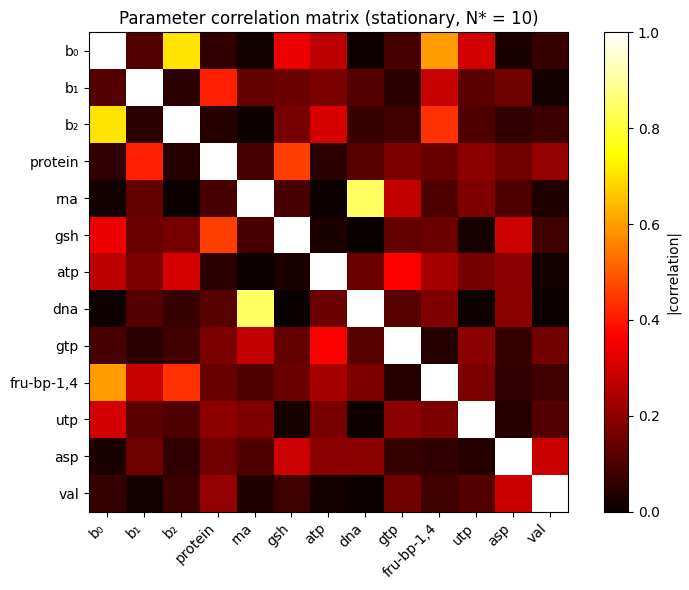

In [16]:
# Correlation matrix at optimal stationary model
X_star_sta = build_design_matrix(x, R, selected_sta[:N_star_sta], baseline_deg)
_, _, _, s2_corr_sta, cov_star_sta, _, _ = fit_model(X_star_sta, y_sta, n_base)

# Convert covariance to correlation (normalise to [-1, 1])
diag_sta = np.sqrt(np.diag(cov_star_sta))
corr_matrix_sta = cov_star_sta / np.outer(diag_sta, diag_sta)

# Parameter labels for axes
param_labels_sta = ["b₀", "b₁", "b₂"] + selected_names_sta

plt.figure(figsize=(8, 6))
plt.imshow(np.abs(corr_matrix_sta), cmap='hot', vmin=0, vmax=1)
plt.colorbar(label="|correlation|")
plt.xticks(range(len(param_labels_sta)), param_labels_sta, rotation=45, ha='right')
plt.yticks(range(len(param_labels_sta)), param_labels_sta)
plt.title(f"Parameter correlation matrix (stationary, N* = {N_star_sta})")
plt.tight_layout()
plt.show()

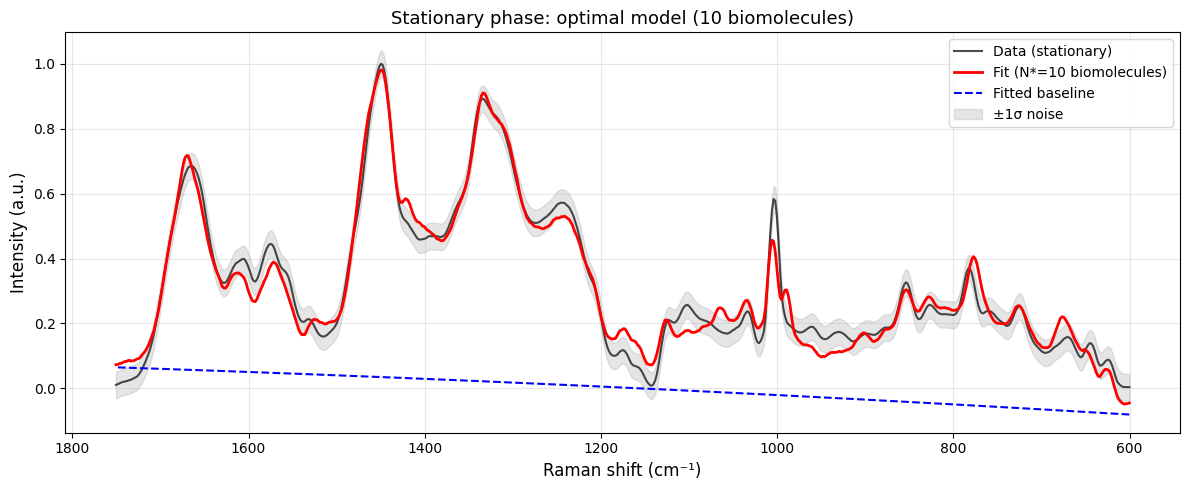

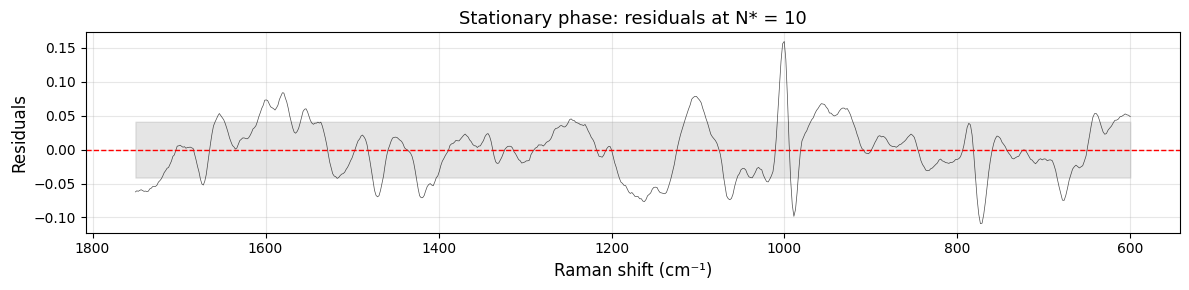

In [17]:
# Fit and residual plots for stationary phase at optimal model
residuals_sta = y_sta - yhat_sta

# Extract fitted baseline
xs = scale_wn(x)
baseline_fit_sta = beta_sta[0] + beta_sta[1]*xs + beta_sta[2]*xs**2

# Top: data vs fitted spectrum with baseline
plt.figure(figsize=(12, 5))
plt.plot(x, y_sta, 'k-', linewidth=1.5, label='Data (stationary)', alpha=0.7)
plt.plot(x, yhat_sta, 'r-', linewidth=2, label=f'Fit (N*={N_star_sta} biomolecules)')
plt.plot(x, baseline_fit_sta, 'b--', linewidth=1.5, label='Fitted baseline')
plt.fill_between(x, y_sta - np.sqrt(s2_sta), y_sta + np.sqrt(s2_sta),
                 alpha=0.2, color='gray', label=r'±1σ noise')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.title(f'Stationary phase: optimal model ({N_star_sta} biomolecules)', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bottom: residuals — should be random and mostly within ±1σ band
plt.figure(figsize=(12, 3))
plt.plot(x, residuals_sta, 'k-', linewidth=0.5, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.fill_between(x, -np.sqrt(s2_sta), +np.sqrt(s2_sta),
                 alpha=0.2, color='gray')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title(f'Stationary phase: residuals at N* = {N_star_sta}', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Stationary Phase: Coefficient Analysis
## How much does each biomolecule contribute?

STATIONARY PHASE: COEFFICIENTS AT N* = 10

Baseline coefficients:
  b0 = 0.0024
  b1 = 0.0728
  b2 = -0.0104

Biomolecule coefficients:
  Biomolecule     Coefficient % of total
----------------------------------------
  protein              0.6735      44.4%
  rna                  0.1867      12.3%
  gsh                  0.1596      10.5%
  atp                  0.1132       7.5%
  dna                  0.1113       7.3%
  gtp                  0.0625       4.1%
  fru-bp-1,4           0.0653       4.3%
  utp                  0.0599       4.0%
  asp                  0.0539       3.6%
  val                  0.0299       2.0%

  Total: 1.5159


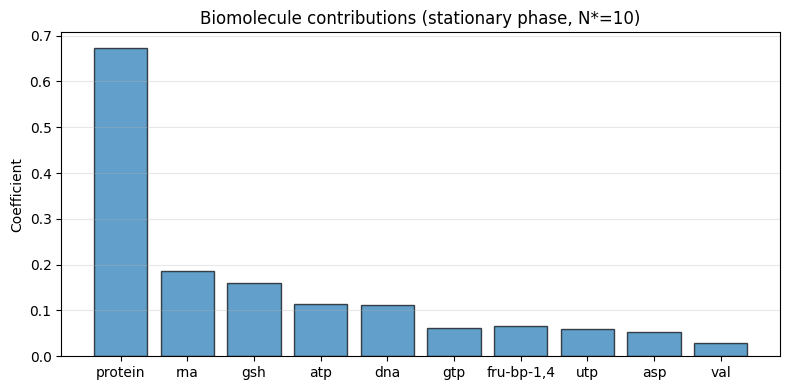

In [18]:
# Extract fitted coefficients at optimal model
baseline_coeffs_sta = beta_sta[:n_base]
coeffs_sta = beta_sta[n_base:]

print("=" * 60)
print(f"STATIONARY PHASE: COEFFICIENTS AT N* = {N_star_sta}")
print("=" * 60)

print(f"\nBaseline coefficients:")
for i, b in enumerate(baseline_coeffs_sta):
    print(f"  b{i} = {b:.4f}")

print(f"\nBiomolecule coefficients:")
print(f"  {'Biomolecule':<14s} {'Coefficient':>12s} {'% of total':>10s}")
print("-" * 40)
total_sta = coeffs_sta.sum()
for name, c in zip(selected_names_sta, coeffs_sta):
    print(f"  {name:<14s} {c:>12.4f} {c/total_sta*100:>9.1f}%")

print(f"\n  Total: {total_sta:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(selected_names_sta, coeffs_sta, edgecolor='black', alpha=0.7)
plt.ylabel('Coefficient')
plt.title(f'Biomolecule contributions (stationary phase, N*={N_star_sta})')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Comparison of Log and Stationary Phase data

COMPARISON: LOG vs STATIONARY PHASE (independent models)

  Biomolecule         Log      Sta  In Log?  In Sta?
--------------------------------------------------
  dna              0.3955   0.1113      yes      yes
  protein          0.4751   0.6735      yes      yes
  rna              0.4092   0.1867      yes      yes
  gsh              0.1148   0.1596      yes      yes
  atp              0.0949   0.1132      yes      yes
  utp              0.0621   0.0599      yes      yes
  gtp              0.0370   0.0625      yes      yes
  glucose          0.0354   0.0000      yes       no
  fru-bp-1,4       0.0000   0.0653       no      yes
  asp              0.0000   0.0539       no      yes
  val              0.0000   0.0299       no      yes


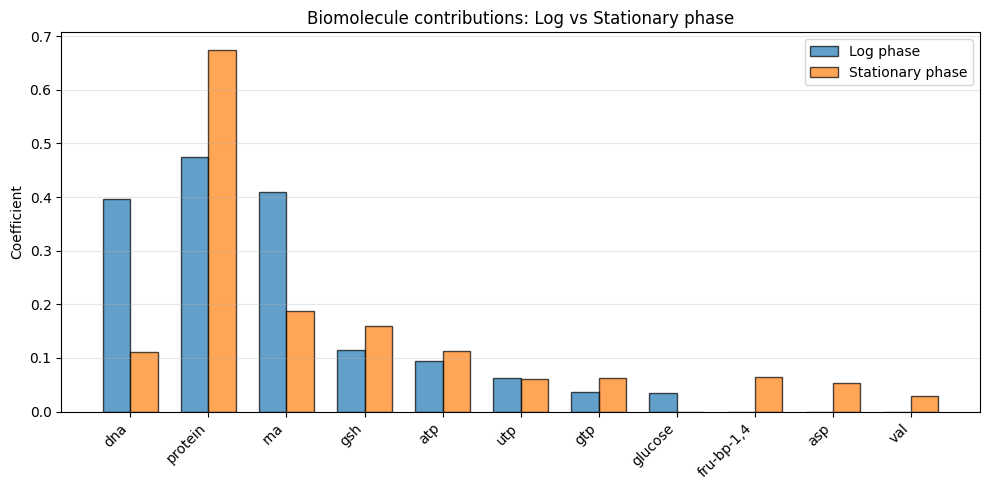

In [19]:
# ===========================
# COMPARISON: LOG vs STATIONARY PHASE
# ===========================

# Union of selected biomolecules from both phases (preserves order, removes duplicates)
all_selected = list(dict.fromkeys(selected_names + selected_names_sta))

# Get coefficients from each phase's own optimal model
beta_log     = history[best_step][11]
beta_sta_own = history_sta[best_step_sta][11]

log_columns = [h[1] for h in history[:N_star]]
sta_columns = [h[1] for h in history_sta[:N_star_sta]]

print("=" * 65)
print("COMPARISON: LOG vs STATIONARY PHASE (independent models)")
print("=" * 65)
print(f"\n  {'Biomolecule':<14s} {'Log':>8s} {'Sta':>8s} {'In Log?':>8s} {'In Sta?':>8s}")
print("-" * 50)

# Collect coefficients for bar chart
c_log_all = []
c_sta_all = []

for name in all_selected:
    column = ref_names.index(name)

    if column in log_columns:
        position = log_columns.index(column)
        c_log = beta_log[n_base + position]
    else:
        c_log = 0.0

    if column in sta_columns:
        position = sta_columns.index(column)
        c_sta = beta_sta_own[n_base + position]
    else:
        c_sta = 0.0

    in_log = "yes" if column in log_columns else "no"
    in_sta = "yes" if column in sta_columns else "no"
    print(f"  {name:<14s} {c_log:>8.4f} {c_sta:>8.4f} {in_log:>8s} {in_sta:>8s}")

    c_log_all.append(c_log)
    c_sta_all.append(c_sta)

# Side-by-side bar chart
x_pos = np.arange(len(all_selected))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x_pos - width/2, c_log_all, width, label='Log phase', edgecolor='black', alpha=0.7)
plt.bar(x_pos + width/2, c_sta_all, width, label='Stationary phase', edgecolor='black', alpha=0.7)
plt.xticks(x_pos, all_selected, rotation=45, ha='right')
plt.ylabel('Coefficient')
plt.title('Biomolecule contributions: Log vs Stationary phase')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Comparison with other common figures of merit (log phase)

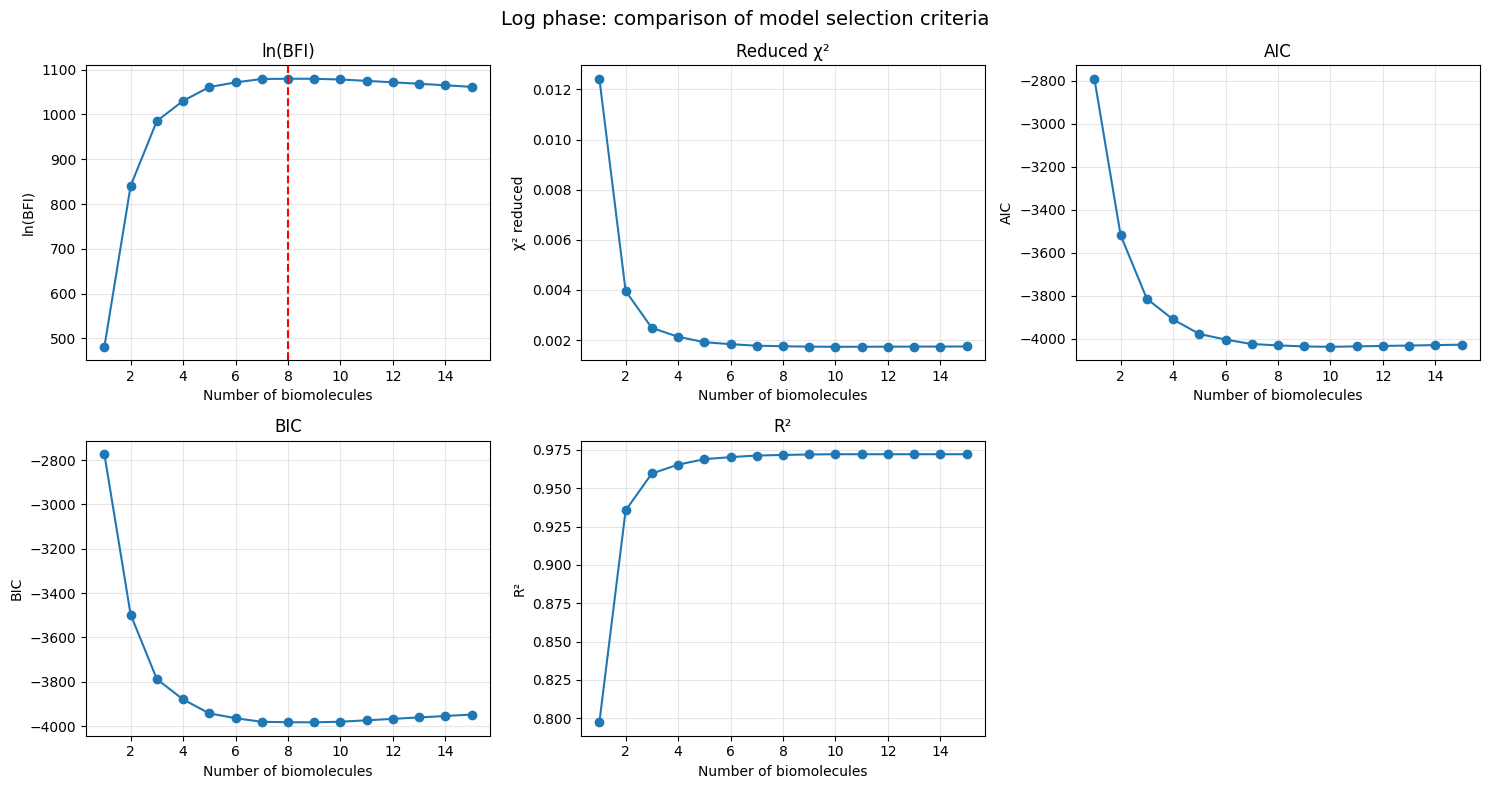

Optimal N* by each criterion:
  ln(BFI):   8
  AIC:      10
  BIC:       9
  χ² red:   10
  R²:       10


In [20]:
# ===========================
# MODEL SELECTION CRITERIA COMPARISON (LOG PHASE)
# ===========================

# Total sum of squares (needed for R²)
y_mean = np.mean(y)
TSS = np.sum((y - y_mean)**2)

# Calculate all criteria at each step from existing history
steps = np.array([h[0] for h in history])
RSS_arr = np.array([h[8] for h in history])
k_arr = np.array([h[5] for h in history])

chi2_red = RSS_arr / (n - k_arr)                        # reduced chi-squared (= s²)
AIC = n * np.log(RSS_arr / n) + 2 * k_arr               # Akaike Information Criterion
BIC = n * np.log(RSS_arr / n) + k_arr * np.log(n)       # Bayesian Information Criterion
R2 = 1 - RSS_arr / TSS                                   # coefficient of determination
lnBFI = np.array([h[3] for h in history])

# Plot all criteria side by side
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(steps, lnBFI, 'o-')
axes[0, 0].axvline(N_star, linestyle='--', color='red')
axes[0, 0].set_ylabel('ln(BFI)')
axes[0, 0].set_title('ln(BFI)')

axes[0, 1].plot(steps, chi2_red, 'o-')
axes[0, 1].set_ylabel('χ² reduced')
axes[0, 1].set_title('Reduced χ²')

axes[0, 2].plot(steps, AIC, 'o-')
axes[0, 2].set_ylabel('AIC')
axes[0, 2].set_title('AIC')

axes[1, 0].plot(steps, BIC, 'o-')
axes[1, 0].set_ylabel('BIC')
axes[1, 0].set_title('BIC')

axes[1, 1].plot(steps, R2, 'o-')
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_title('R²')

axes[1, 2].axis('off')

for ax in axes.flat:
    if ax.axison:
        ax.set_xlabel('Number of biomolecules')
        ax.grid(alpha=0.3)

fig.suptitle('Log phase: comparison of model selection criteria', fontsize=14)
plt.tight_layout()
plt.show()

# Print optimal N* according to each criterion
print("Optimal N* by each criterion:")
print(f"  ln(BFI):  {steps[np.argmax(lnBFI)]:>2d}")
print(f"  AIC:      {steps[np.argmin(AIC)]:>2d}")
print(f"  BIC:      {steps[np.argmin(BIC)]:>2d}")
print(f"  χ² red:   {steps[np.argmin(chi2_red)]:>2d}")
print(f"  R²:       {steps[np.argmax(R2)]:>2d}")

## Model Selection Criteria Comparison (log phase)

- **χ² reduced**: Measures average residual size. No penalty for complexity — always favours more parameters.

- **R²**: Fraction of variance explained. No penalty for complexity — can only increase with more parameters.

- **AIC**: Penalises number of parameters, but ignores parameter correlations. Gives an ambiguous plateau.

- **BIC**: Same as AIC but with a stronger penalty for parameters. Still ignores correlations.

- **ln(BFI)**: Penalises both number of parameters and their correlations via the Occam factor. Gives a clear optimum.


## Optimal N* by each criterion:
  **ln(BFI)**:   8

  **AIC**:      10

  **BIC**:       9

  **χ² reduced**:   10

  **R²**:       10

## Comparison with other common figures of merit (stationary phase)

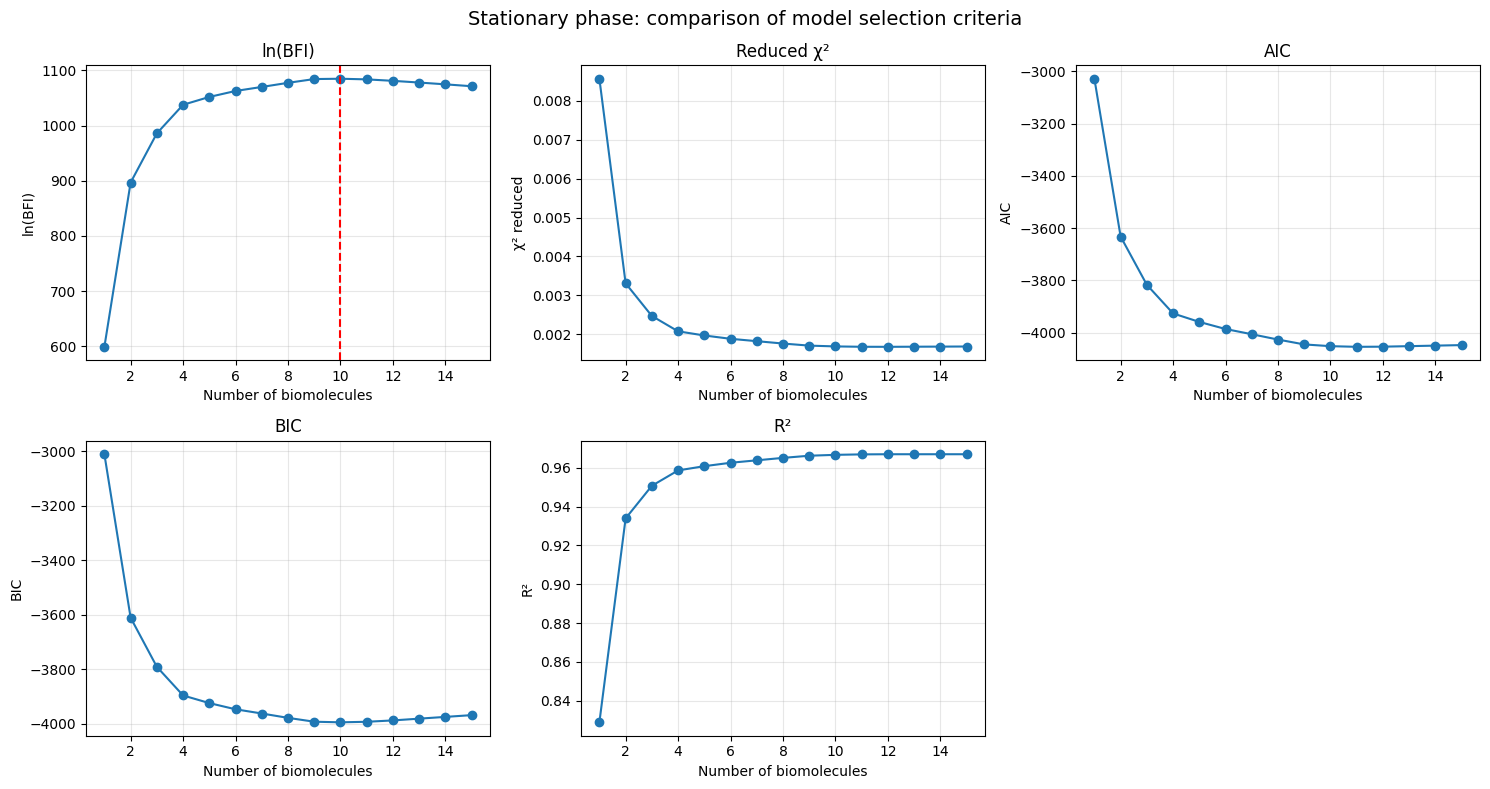

Optimal N* by each criterion:
  ln(BFI):  10
  AIC:      11
  BIC:      10
  χ² red:   12
  R²:       12


In [21]:
# ===========================
# MODEL SELECTION CRITERIA COMPARISON (STATIONARY PHASE)
# ===========================

# Total sum of squares (needed for R²)
y_sta_mean = np.mean(y_sta)
TSS_sta = np.sum((y_sta - y_sta_mean)**2)

# Calculate all criteria at each step from existing history
steps_sta = np.array([h[0] for h in history_sta])
RSS_sta_arr = np.array([h[8] for h in history_sta])
k_sta_arr = np.array([h[5] for h in history_sta])

chi2_red_sta = RSS_sta_arr / (n - k_sta_arr)
AIC_sta = n * np.log(RSS_sta_arr / n) + 2 * k_sta_arr
BIC_sta = n * np.log(RSS_sta_arr / n) + k_sta_arr * np.log(n)
R2_sta = 1 - RSS_sta_arr / TSS_sta
lnBFI_sta = np.array([h[3] for h in history_sta])

# Plot all criteria side by side
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(steps_sta, lnBFI_sta, 'o-')
axes[0, 0].axvline(N_star_sta, linestyle='--', color='red')
axes[0, 0].set_ylabel('ln(BFI)')
axes[0, 0].set_title('ln(BFI)')

axes[0, 1].plot(steps_sta, chi2_red_sta, 'o-')
axes[0, 1].set_ylabel('χ² reduced')
axes[0, 1].set_title('Reduced χ²')

axes[0, 2].plot(steps_sta, AIC_sta, 'o-')
axes[0, 2].set_ylabel('AIC')
axes[0, 2].set_title('AIC')

axes[1, 0].plot(steps_sta, BIC_sta, 'o-')
axes[1, 0].set_ylabel('BIC')
axes[1, 0].set_title('BIC')

axes[1, 1].plot(steps_sta, R2_sta, 'o-')
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_title('R²')

axes[1, 2].axis('off')

for ax in axes.flat:
    if ax.axison:
        ax.set_xlabel('Number of biomolecules')
        ax.grid(alpha=0.3)

fig.suptitle('Stationary phase: comparison of model selection criteria', fontsize=14)
plt.tight_layout()
plt.show()

# Print optimal N* according to each criterion
print("Optimal N* by each criterion:")
print(f"  ln(BFI):  {steps_sta[np.argmax(lnBFI_sta)]:>2d}")
print(f"  AIC:      {steps_sta[np.argmin(AIC_sta)]:>2d}")
print(f"  BIC:      {steps_sta[np.argmin(BIC_sta)]:>2d}")
print(f"  χ² red:   {steps_sta[np.argmin(chi2_red_sta)]:>2d}")
print(f"  R²:       {steps_sta[np.argmax(R2_sta)]:>2d}")

## Above, I gave the different figures of merit the order of biomolecules already chosen from bfi, I assume the order to be the same for all as it is mainly driven by RSS improvement. I am testing below each one on their own to verify they pick the same biomolecules but stop at different points.

LOG PHASE: INDEPENDENT FORWARD SELECTION BY EACH CRITERION

lnBFI:  N* = 8
  Selection order: ['dna', 'protein', 'rna', 'gsh', 'atp', 'utp', 'gtp', 'glucose']

AIC:  N* = 10
  Selection order: ['dna', 'protein', 'rna', 'gsh', 'atp', 'utp', 'gtp', 'glucose', 'fru-bp-1,4', 'glu']

BIC:  N* = 9
  Selection order: ['dna', 'protein', 'rna', 'gsh', 'atp', 'utp', 'gtp', 'glucose', 'fru-bp-1,4']

chi2_red:  N* = 10
  Selection order: ['dna', 'protein', 'rna', 'gsh', 'atp', 'utp', 'gtp', 'glucose', 'fru-bp-1,4', 'glu']

R2:  N* = 10
  Selection order: ['dna', 'protein', 'rna', 'gsh', 'atp', 'utp', 'gtp', 'glucose', 'fru-bp-1,4', 'glu']


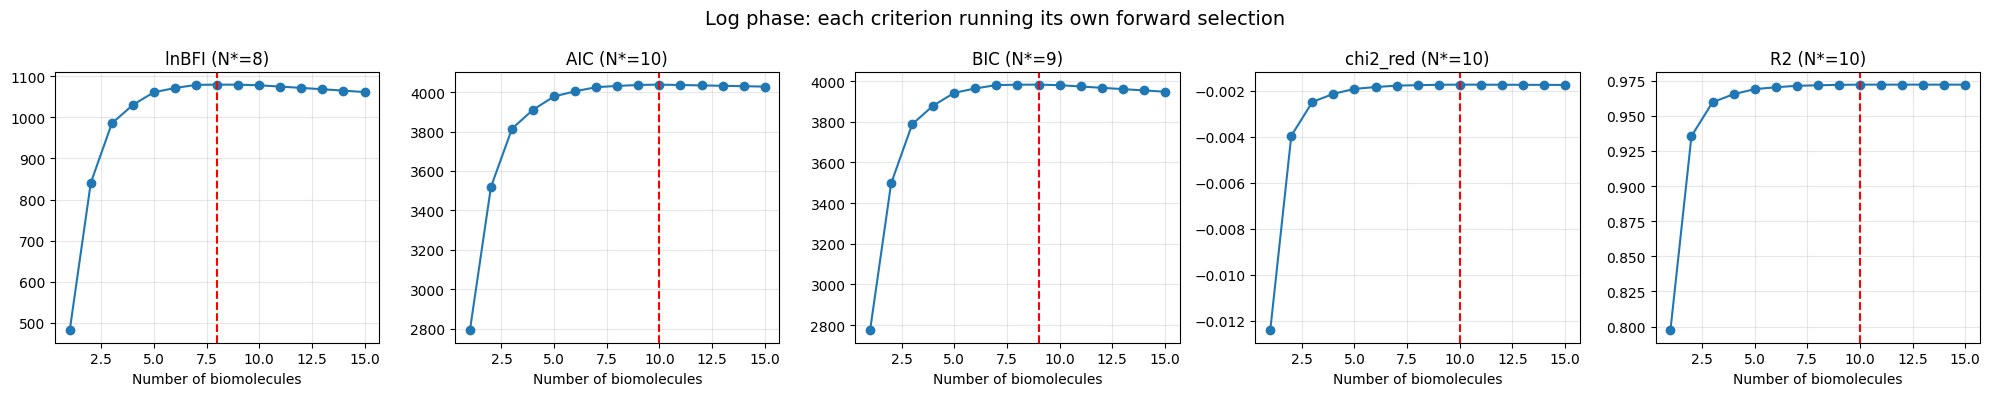

In [22]:
# ===========================
# INDEPENDENT FORWARD SELECTION FOR EACH CRITERION (LOG PHASE)
# ===========================

y_mean = np.mean(y)
TSS = np.sum((y - y_mean)**2)

def score_model(RSS, k, n, covariance, prior_widths, criterion):
    """Return score for a given criterion. Higher = better for all."""
    s2 = RSS / max(n - k, 1)
    if criterion == "lnBFI":
        return ln_bfi(s2, covariance, prior_widths, n, k)
    elif criterion == "AIC":
        return -(n * np.log(RSS / n) + 2 * k)
    elif criterion == "BIC":
        return -(n * np.log(RSS / n) + k * np.log(n))   
    elif criterion == "chi2_red":
        return -(RSS / (n - k))                           
    elif criterion == "R2":
        return 1 - RSS / TSS

criteria = ["lnBFI", "AIC", "BIC", "chi2_red", "R2"]
results = {}

for criterion in criteria:
    selected = []
    best_score_so_far = -np.inf
    best_n_star = 0
    scores = []

    for step in range(1, R.shape[1] + 1):
        best = None

        for column in range(R.shape[1]):
            if column in selected:
                continue

            trial = selected + [column]
            X = build_design_matrix(x, R, trial, baseline_deg)
            beta, yhat, RSS, s2, covariance, rank, condition = fit_model(X, y, n_base)
            prior = np.array([2*bmax]*n_base + [Amax]*len(trial))

            score = score_model(RSS, X.shape[1], n, covariance, prior, criterion)

            if not np.isfinite(score):
                continue
            if best is None or score > best[0]:
                best = (score, column, ref_names[column])

        if best is None:
            break

        selected.append(best[1])
        scores.append(best[0])

    # Find optimum
    scores_arr = np.array(scores)
    best_step = int(np.argmax(scores_arr))
    n_star = best_step + 1
    names = [ref_names[s] for s in selected[:n_star]]
    results[criterion] = {
        "n_star": n_star,
        "scores": scores_arr,
        "selected": [ref_names[s] for s in selected],
        "order": selected
    }

# ===========================
# PRINT COMPARISON
# ===========================
print("=" * 70)
print("LOG PHASE: INDEPENDENT FORWARD SELECTION BY EACH CRITERION")
print("=" * 70)

for criterion in criteria:
    r = results[criterion]
    print(f"\n{criterion}:  N* = {r['n_star']}")
    print(f"  Selection order: {r['selected'][:r['n_star']]}")

# ===========================
# PLOT
# ===========================
fig, axes = plt.subplots(1, len(criteria), figsize=(20, 4))

for i, criterion in enumerate(criteria):
    r = results[criterion]
    steps = np.arange(1, len(r['scores']) + 1)
    axes[i].plot(steps, r['scores'], 'o-')
    axes[i].axvline(r['n_star'], linestyle='--', color='red')
    axes[i].set_xlabel('Number of biomolecules')
    axes[i].set_title(f"{criterion} (N*={r['n_star']})")
    axes[i].grid(alpha=0.3)

fig.suptitle('Log phase: each criterion running its own forward selection', fontsize=14)
plt.tight_layout()
plt.show()